# Week 3 Machine Learning Fundamentals

This notebook covers the core ML concepts for week 3, it has explanations followed by pracrical examples using the same Titanic and Iris datasets cleaned in week 1-2.


**Topic Covered**

- supervised vs unsupervised Learning
- Train/Test split
- Overfitting vs Underfitting
- Model Evaluation Basics

Load the cleaned datasets exported at the end of the week 1-2 notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

titanic_df=pd.read_csv('Titanic-Cleaned.csv')
iris_df=pd.read_csv('Iris-Cleaned.csv')

print("Titanic shape:", titanic_df.shape)
print("Iris shape:", iris_df.shape)
iris_df.head()

Titanic shape: (891, 12)
Iris shape: (150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,-0.900681,1.032057,-1.341272,-1.312977,0
1,-1.143017,-0.124958,-1.341272,-1.312977,0
2,-1.385353,0.337848,-1.398138,-1.312977,0
3,-1.506521,0.106445,-1.284407,-1.312977,0
4,-1.021849,1.263460,-1.341272,-1.312977,0


# 1.Supervised vs Unsupervised Learning

**Supervised Learning**:the model learns from data that already has the correct answers, which can be a label or a target.We show the algorithm many examples of input mapped to the correct output and it learns the mappimg between them.Once trained it predicts the output for nwe unseen inputs.
- Examples include Linear Regression, Logistic Regression, Decision Trees, Random Forest
- Real world use case:Predicting if a Titanic passenger survived, a classification problem. Predicting house prices from its features, a regression problem

**Unsupervised Learning**:the model is given data without labels and has to find the structure or patterns on its own, it groups similar records together or reduces dimentionality.
- Examples:K-means clustering, Hierarchical Clustering, PCA
- Real world use case:Grouping customers into segments based on purchasing bevahiour with no predefined categories.

Below is a demonstration of both using our own datasets.

In [2]:
#Supervised example using Logistic Regression on titanic dataset, predicting survived

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

features=['Pclass','Age','Fare','Sex_male']
X=titanic_df[features]
Y=titanic_df['Survived']

X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, random_state=42)

log_model=LogisticRegression()
log_model.fit(X_train, Y_train)

print("Supervised model trained. Sample predictions", log_model.predict(X_test[:5]))
print("Actual labels:", Y_test[:5].values)

Supervised model trained. Sample predictions [0 0 0 1 1]
Actual labels: [1 0 0 1 1]


In [3]:
#Unsupervised example using K-Means Clustering on Iris Dataset
from sklearn.cluster import KMeans

iris_features= iris_df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

kmeans=KMeans(n_clusters=3, random_state=42, n_init=10)
clusters=kmeans.fit_predict(iris_features)

comparison=pd.DataFrame({'Cluster': clusters, 'Actual Species':iris_df['Species']})
print(comparison.groupby(['Actual Species', 'Cluster']).size())

Actual Species  Cluster
0               1          50
1               0          39
                2          11
2               0          14
                2          36
dtype: int64


**Observation**:The K-Means clusters line up reasonably well with the actual species group even though the algorithm never saw the species labels. This shows that unsupervised learning can uncover structure that mirror real categories.


# 2.Train/Test Split
We split data into training set which is used to fit the model and a testing set used to check how well the model performs on data it has not seen, it helps in providing an early warning sign because the model may perform well on training set and not as well on test set.

**Recommenation ratio**:commonly 80% train/test.Testing before deployment matters because a model that looks perfect on training can fail on new data.

In [4]:
#Train/Test Split on iris dataset
X_iris=iris_df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
Y_iris=iris_df['Species']

X_train_i,X_test_i,Y_train_i,Y_test_i=train_test_split(X_iris, Y_iris, test_size=0.2, random_state=42)

print(f"Trainig set:{X_train_i.shape[0]} rows")
print(f"Testing set:{X_test_i.shape[0]} rows")
print(f"Split ratio:{X_train_i.shape[0]/len(X_iris):.0%} train / {X_test_i.shape[0]/len(X_iris):.0%} test")

Trainig set:120 rows
Testing set:30 rows
Split ratio:80% train / 20% test


# 3.Overfiiting vs Underfitting
- **Overfitting**:The model learns the training data too well, including the data's noise so it performs great on training data but poorly on new/test data.It has memorised rather than learned.
- **Underfitting**:The model is too simple to capture the real pattern int the data, so it perfoms poorly on both training and test data.

 **How to reduce them**
 - **Overfitting**:simplify the model by using fewer features or lowering complexity, use more training data, apply regulisation, use cross validation, prune decision trees.
 - **Underfitting**:use a more complex/appropriate model, add more relevant features, train for longer/reduce regulisation.

We can demonstrate this directly with a decision tree on the Titanic dataset by Varying its max_depth

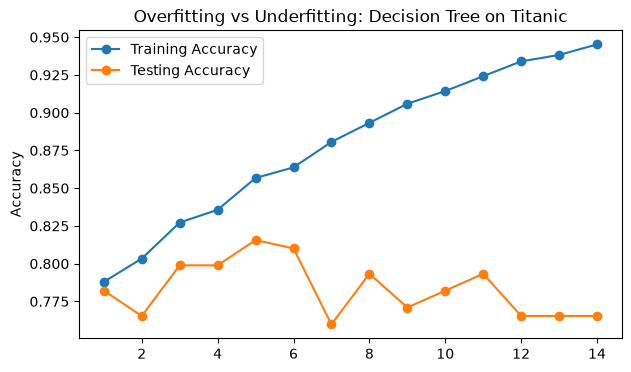

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths=range(1,15)
train_scores, test_scores= [],[]

for d in depths:
    tree=DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, Y_train)
    train_scores.append(accuracy_score(Y_train, tree.predict(X_train)))
    test_scores.append(accuracy_score(Y_test, tree.predict(X_test)))

plt.figure(figsize=(7,4))
plt.plot(depths, train_scores, marker='o', label='Training Accuracy')
plt.plot(depths, test_scores, marker='o', label='Testing Accuracy')
plt.ylabel('Accuracy')
plt.title('Overfitting vs Underfitting: Decision Tree on Titanic')
plt.legend()
plt.show()


The chart shows that at very low depth, both training and teting accuracy are low therefore its **underfitting**, as depth increases, training accuracy keeps climbing while testing accuracy drops, the gap that opens up is **overfitting**.The best depth is where testing accuracy peaks,just before the gap widens.

# 4.Model Evaluation Basics
Once the model makes prediction we need to judge how good it really is:
- **Accuracy**:the percentage of predictions the model got right overall.Simple but can be misleading on imbalanced dataset(if 90% of passengers didn't survive, a model that always predicts "died" gets 90% accuracy while being useless).
- **Confusion Matrix**:a table comparing predicted vs actual classes, showing True Positives, True Negatives, False Positives and False Negatives.It shows what kind of mistakes the model makes, not just how many.
- **Precision**:of everything the model predictited as positive, what fraction was actually correct?
- **Recall**:of everything that was actually positive, what fraction did the model correctly catch?

A model performs well when these metrics are consistently strong on the test set, not just the training set.

Accuracy:81.01%

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.87      0.84       105
       Survived       0.79      0.73      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179



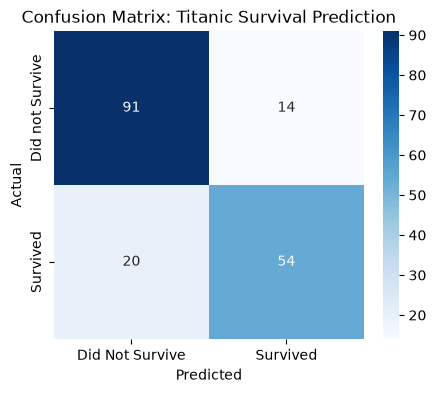

In [8]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_pred=log_model.predict(X_test)

acc=accuracy_score(Y_test, y_pred)
print(f"Accuracy:{acc:.2%}\n")

print("Classification Report:")
print(classification_report(Y_test, y_pred, target_names=['Did Not Survive','Survived']))

cm=confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive','Survived'],
            yticklabels=['Did not Survive','Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Titanic Survival Prediction')
plt.show()

The results show that higher accuracy means more predictions were correct overall.Higher precision means fewer "False alarms".Higher recall means fewer missed survivors.The Confusion matrix makes it easy to see exactly which of these errors the model is making.

# Summary
- **Supervised learning** uses labeled data to predict outcomes,**unsupervised learning** finds structure without labels.
- **Train/test splitting** lets us honestly evaluate a model on data it hasn't seen, catching problems before deployment.
- **Overfitting**(too complex, memorizes noise) and **underfitting**(too simple, misses the pattern) are opposite failure modes, the sweet spot becomes the model complexity where test performance peaks.
- **Accuracy**,**precision**,**recall** and **confusion matrix** together give a fulle